In [1]:
pip install datasets


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("scikit-learn/adult-census-income")
print(dataset)
# Save locally as CSV
dataset["train"].to_csv("adult_census_income_train.csv")


DatasetDict({
    train: Dataset({
        features: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income'],
        num_rows: 32561
    })
})


Creating CSV from Arrow format: 100%|██████████| 33/33 [00:00<00:00, 112.05ba/s]


3551168

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset("scikit-learn/adult-census-income", split="train")
# Downloads only the training split of the Adult Census Income dataset.
# split="train" means you don't load the test data.

# Convert to Pandas DataFrame for easier manipulation
df = dataset.to_pandas()

# 2. Basic Inspection
print(f"Dataset Shape: {df.shape}")
print("-" * 30)
print("First 5 rows:")
display(df.head())

Dataset Shape: (32561, 15)
------------------------------
First 5 rows:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
type(dataset)

datasets.arrow_dataset.Dataset

In [61]:
# 3. Data Types and Null Values
print("\nData Info:")
print(df.info())

# 4. Statistical Summary
print("\nNumerical Statistics:")
display(df.describe())


Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB
None

Numerical Statistics:


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
print("\nCategorical Statistics:")
display(df.describe(include=['string', 'category']))


Categorical Statistics:


,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [62]:
# TO find out what the top does
df['workclass'].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [63]:
df['workclass'].unique()

<ArrowStringArray>
[               '?',          'Private',        'State-gov',
      'Federal-gov', 'Self-emp-not-inc',     'Self-emp-inc',
        'Local-gov',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

In [9]:
df['workclass'].nunique()

9

#### Univariate Analysis (Distributions)
Univariate Analysis is one of the first steps in Exploratory Data Analysis (EDA).

Let's break down the term:

Uni = One
Variate (Variable) = One column or one feature

So,

Univariate Analysis means analyzing one variable (one column) at a time.

The purpose is to understand the distribution and characteristics of a single variable without considering its relationship with other variables.

#### What is "Distributions"?

A distribution tells you how the values of a variable are spread.

For example, consider the age column:

18, 20, 21, 22, 22, 24, 25, 25, 26, 60

Questions answered by the distribution include:

Are most people young or old?
Is the data spread evenly?
Are there any outliers?
Is the data skewed?
Which values occur most frequently?

In [64]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
32556    False
32557    False
32558    False
32559    False
32560    False
Length: 32561, dtype: bool

In [65]:
df.duplicated().sum()

np.int64(24)

In [66]:
df.drop_duplicates()   

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [67]:
df = df.drop_duplicates()

In [68]:
# here the 24 duplicated rows has been deleted

df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [15]:
df.shape

(32537, 15)

In [69]:
df['income'].nunique()

2

In [70]:
df['income'].value_counts()

income
<=50K    24698
>50K      7839
Name: count, dtype: int64

In [18]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
# idea at first we can check the each column whether there is any ? value or not using for loop and list of columns name so that to be sure where are ? values 

In [71]:
df["workclass"].value_counts()

workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [72]:
import numpy as np

In [73]:

# at first we are removing the ? sign by np.nan values 
df.replace('?', np.nan, inplace=True)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [74]:
df['workclass'].value_counts()

workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [75]:
df['workclass'].value_counts().sum()

np.int64(30701)

In [79]:
# shortcut to find out the columns that do not have values
df.info()

<class 'pandas.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32537 non-null  int64
 1   workclass       30701 non-null  str  
 2   fnlwgt          32537 non-null  int64
 3   education       32537 non-null  str  
 4   education.num   32537 non-null  int64
 5   marital.status  32537 non-null  str  
 6   occupation      30694 non-null  str  
 7   relationship    32537 non-null  str  
 8   race            32537 non-null  str  
 9   sex             32537 non-null  str  
 10  capital.gain    32537 non-null  int64
 11  capital.loss    32537 non-null  int64
 12  hours.per.week  32537 non-null  int64
 13  native.country  31955 non-null  str  
 14  income          32537 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.5 MB


In [77]:
df.shape

(32537, 15)

In [80]:
df['workclass']=df['workclass'].ffill()
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [82]:
# this much amount of data has been filled
df['workclass'].value_counts().sum()

np.int64(32536)

In [83]:
# remaining one so backfill
df['workclass'].bfill()

0        Private
1        Private
2        Private
3        Private
4        Private
          ...   
32556    Private
32557    Private
32558    Private
32559    Private
32560    Private
Name: workclass, Length: 32537, dtype: str

In [27]:
# again bfill beacuse the first row was nan
df['workclass'] = df['workclass'].bfill()

In [28]:
df['workclass'].value_counts().sum()


np.int64(32537)

In [85]:
df['occupation'].value_counts()

occupation
Prof-specialty       4136
Craft-repair         4094
Exec-managerial      4065
Adm-clerical         3768
Sales                3650
Other-service        3291
Machine-op-inspct    2000
Transport-moving     1597
Handlers-cleaners    1369
Farming-fishing       992
Tech-support          927
Protective-serv       649
Priv-house-serv       147
Armed-Forces            9
Name: count, dtype: int64

In [86]:
df['occupation'].isnull().sum()

np.int64(1843)

In [31]:
df['occupation'].value_counts().sum()

np.int64(30694)

In [87]:
oc_mode =df['occupation'].mode()[0]

In [88]:
oc_mode

'Prof-specialty'

In [90]:
type(oc_mode)

str

In [91]:
df['occupation'] =df['occupation'].fillna(oc_mode)
df['occupation'].isnull().sum()

np.int64(0)

In [92]:
df['occupation'].value_counts().sum()

np.int64(32537)

In [37]:
# another way to fill the occupation field
df.fillna({'occupation': oc_mode}, inplace=True)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [38]:
df['occupation'].value_counts()
# we can make piechart, barchart

occupation
Prof-specialty       5979
Craft-repair         4094
Exec-managerial      4065
Adm-clerical         3768
Sales                3650
Other-service        3291
Machine-op-inspct    2000
Transport-moving     1597
Handlers-cleaners    1369
Farming-fishing       992
Tech-support          927
Protective-serv       649
Priv-house-serv       147
Armed-Forces            9
Name: count, dtype: int64

In [39]:
df.isnull().sum()

age                 0
workclass           0
fnlwgt              0
education           0
education.num       0
marital.status      0
occupation          0
relationship        0
race                0
sex                 0
capital.gain        0
capital.loss        0
hours.per.week      0
native.country    582
income              0
dtype: int64

In [40]:
# as 582 values are nan of native.country column so filling it
df['native.country'] =df['native.country'].ffill()

In [41]:
df['native.country'].isnull().sum()

np.int64(0)

In [42]:
# is there any duplicated value 
df.duplicated().sum()

np.int64(0)

In [43]:
df.drop_duplicates()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [44]:
df.shape

(32537, 15)

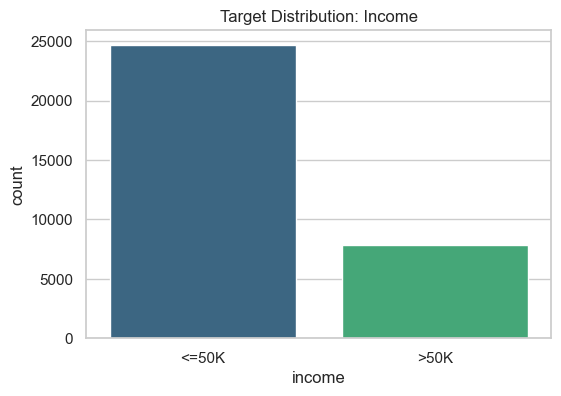

In [93]:
sns.set(style="whitegrid")

# 1. Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='income', data=df, hue="income", palette='viridis')
plt.title('Target Distribution: Income')
plt.show()

In [46]:
# mostly almost 75 % people earn less than 50,000

In [47]:
# 2. Numerical Distribution (Histograms)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [48]:
num_cols

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='str')

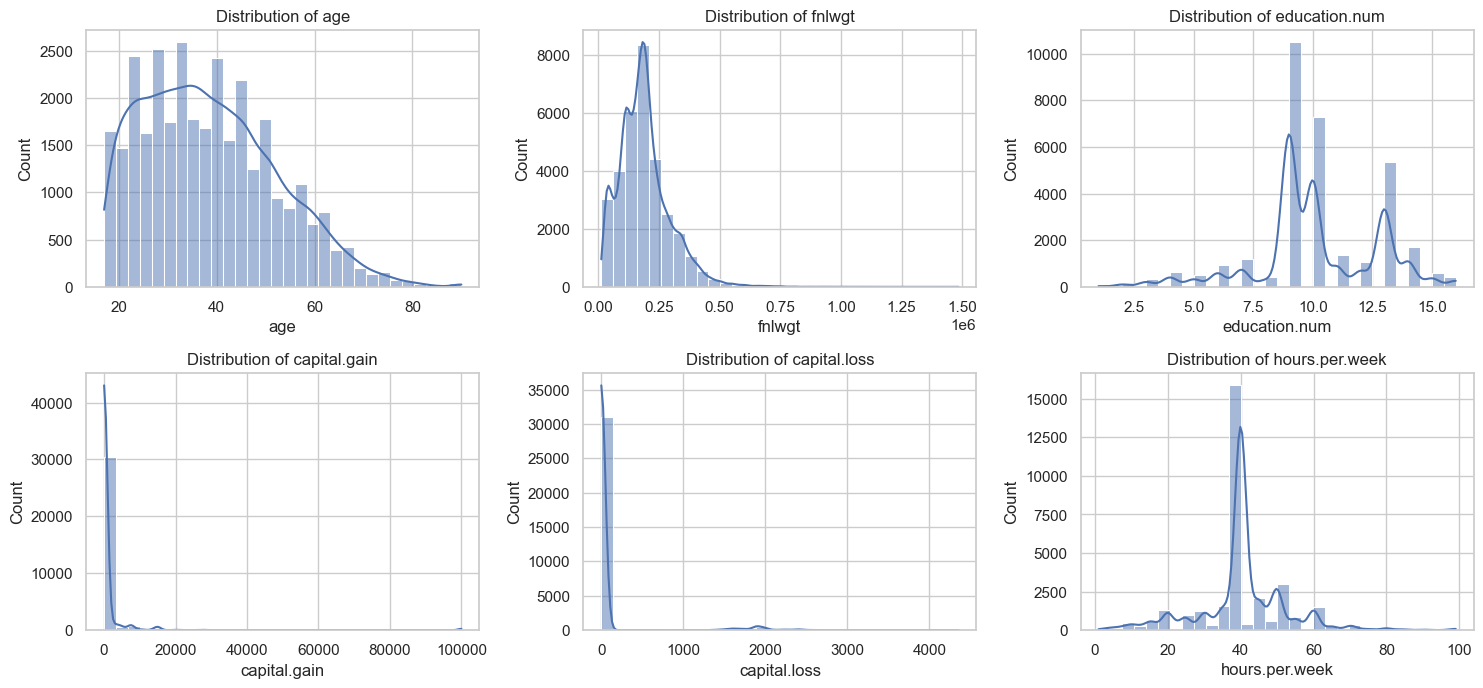

In [49]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Age: Most people are between 20–50 years. The distribution is right-skewed (fewer older people).

fnlwgt: Most values are concentrated at lower weights with a long right tail.

education.num: Peaks at common education levels (e.g., 9 = High School, 13 = Bachelor's).

capital.gain: Most people have 0 capital gain; only a few have very high values.

capital.loss: Most people have 0 capital loss; very few have non-zero values.

hours.per.week: Most people work around 40 hours per week, creating a large peak at 40.


### What do these plots tell us?

They help us understand:

The shape of the data (normal, skewed, etc.).

Where most values are concentrated.

Whether there are outliers.

Whether the data is balanced or heavily concentrated around certain values.

This is a key part of Univariate Analysis because you're examining one numerical column at a time.
    

In [94]:
df['education'].value_counts()

education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           332
1st-4th           166
Preschool          50
Name: count, dtype: int64

In [51]:
df['education.num'].value_counts()

education.num
9     10494
10     7282
13     5353
14     1722
11     1382
7      1175
12     1067
6       933
4       645
15      576
5       514
8       433
16      413
3       332
2       166
1        50
Name: count, dtype: int64

In [52]:
df["capital.loss"].value_counts() # useless columns as 31018 data are 0 

capital.loss
0       31018
1902      202
1977      168
1887      159
1848       51
        ...  
1944        1
1844        1
1539        1
1411        1
155         1
Name: count, Length: 92, dtype: int64

In [53]:
df["capital.gain"].value_counts() # useless columns as 29825 data are 0 

capital.gain
0        29825
15024      347
7688       284
7298       246
99999      159
         ...  
2538         1
2387         1
1639         1
1455         1
1111         1
Name: count, Length: 119, dtype: int64

In [54]:
# practice
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

ValueError: num must be an integer with 1 <= num <= 9, not 0

<Figure size 1500x1000 with 0 Axes>

In [95]:
df['capital.gain'].value_counts()

capital.gain
0        29825
15024      347
7688       284
7298       246
99999      159
         ...  
2538         1
2387         1
1639         1
1455         1
1111         1
Name: count, Length: 119, dtype: int64

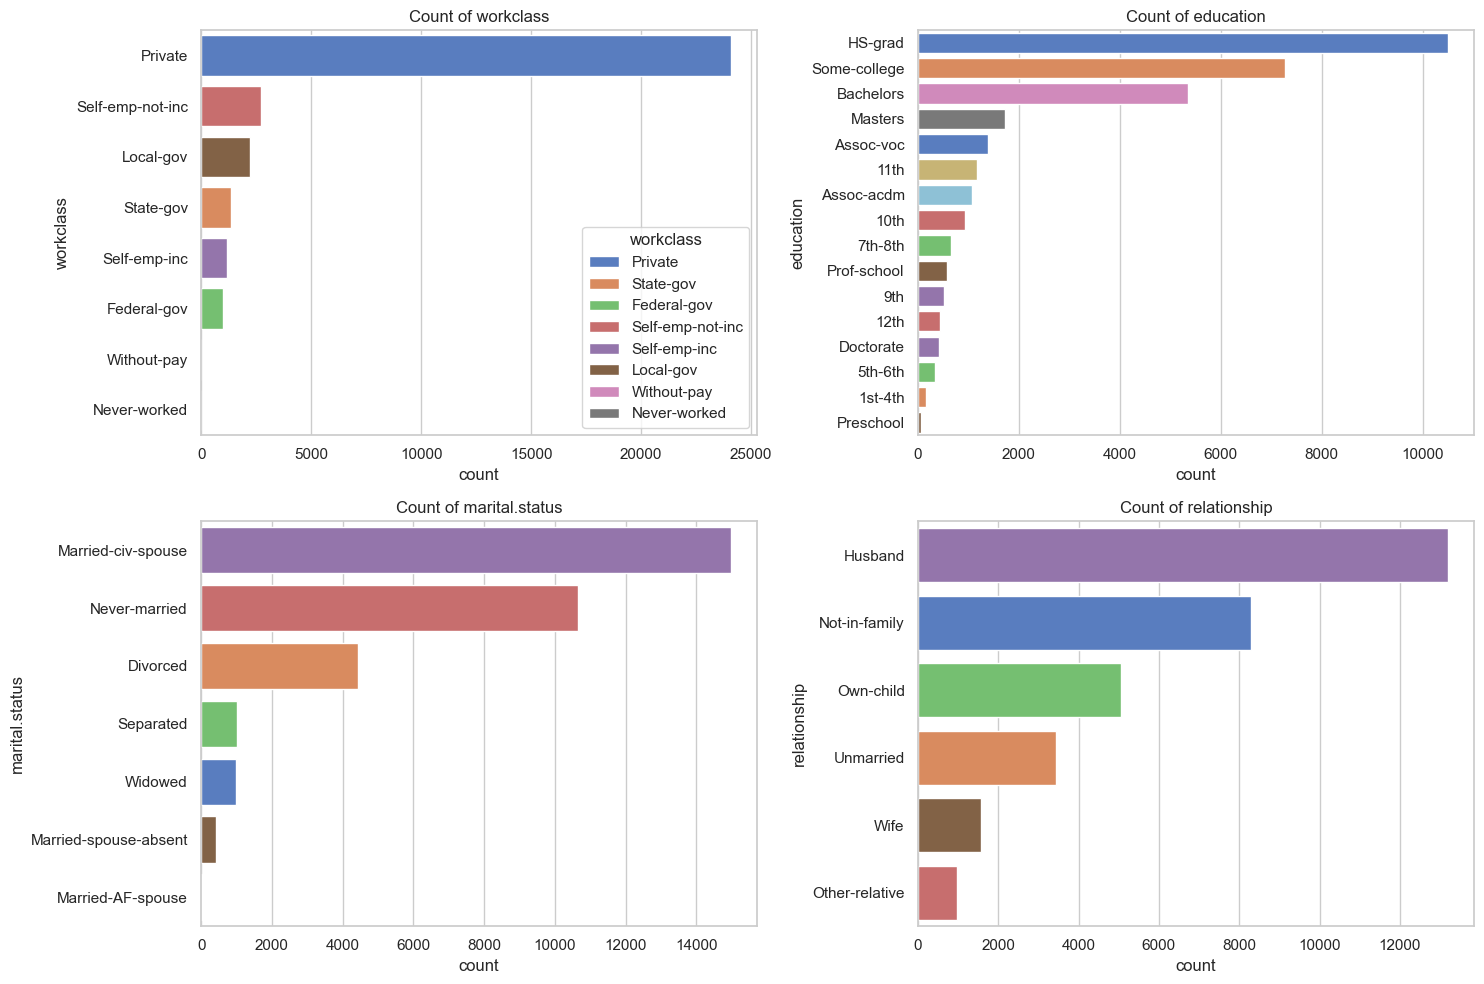

In [96]:
# 3. Categorical Distribution
cat_cols = ['workclass', 'education', 'marital.status', 'relationship']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(y=col, data=df, order=df[col].value_counts().index, hue=col, palette='muted')
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

This figure shows Univariate Analysis for Categorical Variables using count plots.

Unlike the previous histograms (used for numerical columns), count plots are used for categorical columns.

What is a Count Plot?

A count plot shows how many times each category appears in a column.

1. Workclass

Question: Which type of employer do people work for?

Private has the highest count (most people work in private companies).

Self-employed, Local-gov, and State-gov have much fewer people.

Without-pay and Never-worked are very rare.

Conclusion: Most individuals in this dataset work in the private sector.

2. Education

Question: What is the highest education level of people?

HS-grad (High School Graduate) is the most common.

Some-college is the second most common.

Bachelors is also common.

Doctorate and Preschool are rare.

Conclusion: Most people have completed high school or some college.

3. Marital Status

Question: What is the marital status of people?

Married-civ-spouse has the highest count.

Never-married is the second largest group.

Divorced comes next.

Other categories have relatively few people.

Conclusion: The dataset contains mostly married individuals.

4. Relationship

Question: What is each person's relationship within their household?

Examples:

Husband
Wife
Own-child
Not-in-family

The plot shows:

Husband is the largest category.

Not-in-family is second.

Own-child is also common.

Other-relative is the least common.

Conclusion: Most records represent people whose relationship category is Husband.

Why are we making these plots?

These count plots help us:

Find the most common category.

Find rare categories.

Check whether the data is balanced or imbalanced.

Understand the dataset before cleaning or building a machine learning model.

This is still Univariate Analysis, because we're analyzing one categorical column at a time.

In [ ]:
### Handling Outliers - IQR Method

## Understanding IQR
** Outliers can skew statistical measures and ruin model performance (especially linear models).

** IQR: The difference between the 75th percentile (Q3) and the 25th percentile (Q1).
** IQR = Q3 - Q1
|
** Bounds: Lower = Q1 - 1.5IQR, 
** Upper = Q3 + 1.5IQR

In [ ]:
Q1 = df['column'].quantile(0.25)
Q3 = df['column'].quantile(0.75)`

### Visualizing Outliers

In [ ]:
df["age"].value_counts()

In [ ]:
df["age"].min()

In [ ]:
df["age"].max()

In [ ]:
df["age"].quantile(0.25)

In [ ]:
df["age"].quantile(0.75)

In [ ]:
(20* 1.5) + 48

In [ ]:
df[df["age"]> 78]

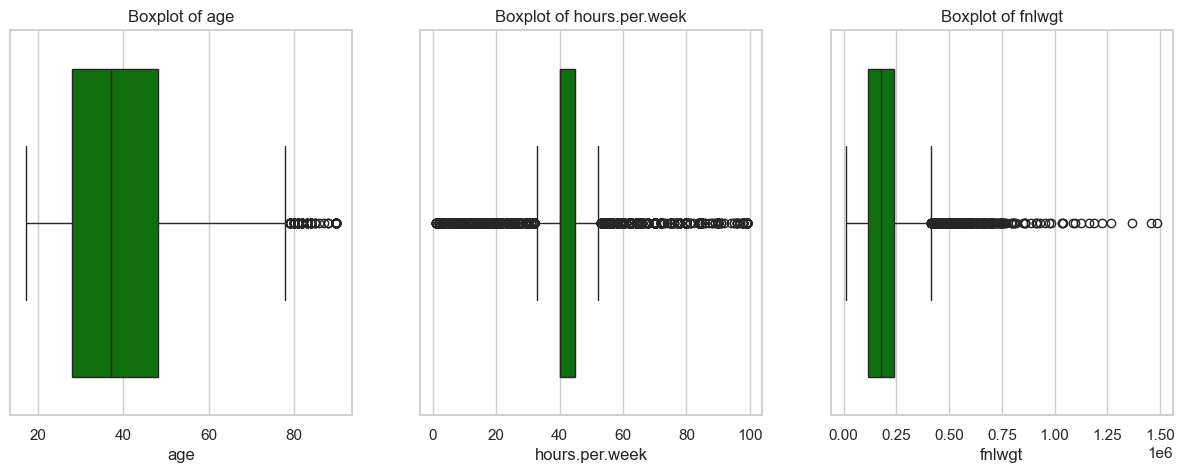

In [97]:
# Focus on numerical columns that looked skewed on Day 1
focus_cols = ['age', 'hours.per.week', 'fnlwgt']

plt.figure(figsize=(15, 5))
for i, col in enumerate(focus_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=df[col], color='green')
    plt.title(f'Boxplot of {col}')
plt.show()

In [98]:
# checking boxplot of hours.per.week 
q1 = df["hours.per.week"].quantile(0.25)
q3 = df["hours.per.week"].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR
print(f"q1 = {q1}, q3 = {q3}, lower_bound = {lower_bound}, upper_bound = {upper_bound}")
# now i am finding whether the max value of hours.per.wewk coincide with the upper_bound value and the min value of hours.per.wewk coincide with the lower_bound value
print(f"Minimum value = {df["hours.per.week"].min()}")
print(f"maximum value = {df["hours.per.week"].max()}")
# this is wrong


q1 = 40.0, q3 = 45.0, lower_bound = 32.5, upper_bound = 52.5
Minimum value = 1
maximum value = 99


In [99]:
# df[(df["hours.per.week"] == 32.5) | (df["hours.per.week"]== 52.5)]
print(df[(df["hours.per.week"] == 32)].head())
print("\n")
print(df[(df["hours.per.week"] == 52)].head())

     age         workclass  fnlwgt  education  education.num  \
24    61           Private  135285    HS-grad              9   
26    33           Private  228696    1st-4th              2   
390   63  Self-emp-not-inc   35021  Bachelors             13   
624   32           Private  127610  Bachelors             13   
648   43           Private  112181  Assoc-voc             11   

         marital.status      occupation   relationship                race  \
24   Married-civ-spouse  Prof-specialty        Husband               White   
26   Married-civ-spouse    Craft-repair  Not-in-family               White   
390  Married-civ-spouse  Prof-specialty        Husband  Asian-Pac-Islander   
624  Married-civ-spouse  Prof-specialty           Wife               White   
648  Married-civ-spouse    Tech-support           Wife               White   

        sex  capital.gain  capital.loss  hours.per.week native.country income  
24     Male             0          2603              32  United-St

In [100]:
def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(f"Column: {column} | IQR: {IQR} | Lower: {lower_bound} | Upper: {upper_bound}")
    
    # Let's check how many outliers we have
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"Number of outliers identified: {len(outliers)}")

    
    # Strategy: Capping (Winsorizing)
    # We cap values to the upper and lower bounds instead of deleting rows (to preserve data)
    
    df_clean = df.copy()
    df_clean[column] = np.where(df_clean[column] > upper_bound, upper_bound,
                                np.where(df_clean[column] < lower_bound, lower_bound, df_clean[column]))
    
    return df_clean

Column: hours.per.week | IQR: 5.0 | Lower: 32.5 | Upper: 52.5
Number of outliers identified: 0
Column: age | IQR: 20.0 | Lower: -2.0 | Upper: 78.0
Number of outliers identified: 0
Column: fnlwgt | IQR: 119166.0 | Lower: -60922.0 | Upper: 415742.0
Number of outliers identified: 0
Column: capital.gain | IQR: 0.0 | Lower: 0.0 | Upper: 0.0
Number of outliers identified: 2712


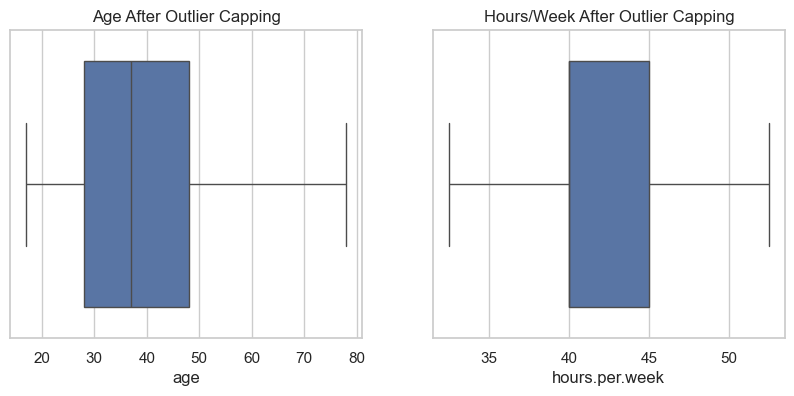

In [92]:
# Apply to specific columns
# Let's apply it to 'hours.per.week' and 'age'
df = handle_outliers_iqr(df, 'hours.per.week')
df = handle_outliers_iqr(df, 'age')
df = handle_outliers_iqr(df, 'fnlwgt')

df = handle_outliers_iqr(df, 'capital.gain')

# Visualize After Capping
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['age'])
plt.title('Age After Outlier Capping')


plt.subplot(1, 2, 2)
sns.boxplot(x=df['hours.per.week'])
plt.title('Hours/Week After Outlier Capping')
plt.show()

In [73]:
q1 = df["hours.per.week"].quantile(0.25)
q2 = df["hours.per.week"].quantile(0.50)
print(q1);print(q2)

40.0
40.0


In [ ]:
### Feature Scaling - Normalization & Standardization

In [74]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.3 MB 5.4 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.3 MB 6.4 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.3 MB 6.6 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 6.5 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 6.3 MB/s  0:00:01
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.3/37.3 MB 7.0 MB/s eta 0:00:06
   --- ------------------------------------ 2.9/37.3 MB 7.2 MB/s eta 0:00:05
   ---- ----------------------------------- 4.5/37.3 MB 7.1 MB/s eta 0:00:05
   ------ --------------------------------- 6.0/37.3 MB 7.2 MB/s eta 0:00:05
   ------- --------------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
### Theory

In [ ]:
Normalization (Min-Max Scaling): Scales data between 0 and 1. Good when data doesn't follow a Gaussian distribution.

Standardization (Z-Score Scaling): Scales data to have Mean=0 and Std Dev=1. Good when data follows a Gaussian distribution
or when algorithms assume it (Logistic Regression, SVM).

## Data Scaling

### Why do we scale data?
Different features can have very different numerical ranges.

Example:
- Age → 20–60
- Salary → 20,000–100,000

Large numerical values can have a greater effect on calculations in some ML algorithms. Scaling puts features on a comparable scale.

### 1. Normalization (Min-Max Scaling)
- Converts values usually between **0 and 1**.
- Formula: `(X - min) / (max - min)`
- Example: `20 → 0`, `40 → 0.5`, `60 → 1`
- **Think:** "Where is this value between the minimum and maximum?"

### 2. Standardization (Z-Score Scaling)
- Makes **Mean = 0** and **Standard Deviation = 1**.
- Formula: `Z = (X - mean) / standard deviation`
- Negative → below average
- 0 → around average
- Positive → above average
- **Think:** "How far is this value from the average?"

### Easy Difference

| Normalization | Standardization |
|---|---|
| Usually 0 to 1 | Mean = 0, Std = 1 |
| Uses minimum & maximum | Uses mean & standard deviation |
| Fixed range | No fixed range |

**Remember:**  
Normalization = **0 to 1**  
Standardization = **distance from the mean**

> Note: Don't strictly memorize "Gaussian = Standardization, non-Gaussian = Normalization." The choice depends on the data and the ML algorithm.

# Feature Scaling / Normalization — Why It Matters

## Without Scaling
When features are on very different scales (e.g., age vs. income):

- ❌ **Slow or failed convergence**
- ❌ **Biased feature importance**
- ❌ **Poor model performance**


---

## With Scaling
After scaling features to a similar range:

- ✅ **Faster training**
- ✅ **Better accuracy**
- ✅ **More stable gradients**
- ✅ **Fair feature contribution**

**Why?**  
All features contribute more evenly, helping gradient-based optimizers move efficiently toward the optimum.

---

# Feature Scaling / Normalization — Why It Matters

## Why do we scale data?

Different features can have very different numerical ranges.

Example:

- Age → 20–60
- Income → 20,000–100,000

Large numerical values can have a greater effect on calculations in some ML algorithms.

**Scaling puts features on a comparable scale.**

---

## Without Scaling

- ❌ **Slower training:** The algorithm may need more steps to find the best solution.
- ❌ **Unequal influence:** A feature with very large numbers may have a greater effect on calculations.
- ❌ **Poor model performance:** Some ML algorithms may not work as well when features have very different scales.
- ❌ **Unstable gradients:** In gradient-based algorithms, differently scaled features can make the learning process move unevenly.

### What is a Gradient?

A **gradient tells the algorithm which direction it should move to reduce the error (loss).**

Think of it like walking down a hill:

- The **gradient** tells you which direction the hill goes.
- The algorithm uses this information to move toward the **lowest point**, where the error is smaller.

If features have very different scales, the path toward the lowest point can become inefficient, so the algorithm may take longer to reach the best solution.

---

## With Scaling

After scaling the features to a similar range:

- ✅ **Faster training**
- ✅ **Better model performance**
- ✅ **More stable gradients**
- ✅ **Features are on a comparable scale**

### Simple Example

Before scaling:

```text
Age       → 20–60
Income    → 20,000–100,000
After scaling:

Age       → 0–1
Income    → 0–1
Why scaling?
Some ML algorithms perform mathematical calculations using feature values.


## Simple Intuition
> **Normalization = “Put everything between 0 and 1”**

This prevents one feature from overpowering the others just because of its units.

---

## Common Scaling Methods

### 1. Min–Max Normalization
Scales values to \([0, 1]\)

$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$


Best when:
- You want a fixed range
- No extreme outliers

---

Best when:
- Data is roughly normal
- Using models like Logistic Regression, SVM, Linear Regression

---


In [101]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Isolate numerical columns to scale
cols_to_scale = ['age', 'fnlwgt', 'education.num', 'hours.per.week', 'capital.gain', 'capital.loss']

# 1. Standardization (Preferred for this dataset which has outliers/variance)
scaler_std = StandardScaler()

# Create a copy to keep original for comparison
df_scaled = df.copy()


df_scaled[cols_to_scale] = scaler_std.fit_transform(df[cols_to_scale])

# df_scaled
# ↓
# Same dataset, but selected numerical columns are standardized

In [103]:
# after standard scalization of the columns_to_scale all the values has become 0,1,-1,etc.
    
df_scaled

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,3.770003,NaN,-1.067955,HS-grad,-0.420679,Widowed,Prof-specialty,Not-in-family,White,Female,-0.145975,10.589625,-0.035664,United-States,<=50K
1,3.183397,Private,-0.539159,HS-grad,-0.420679,Widowed,Exec-managerial,Not-in-family,White,Female,-0.145975,10.589625,-1.817516,United-States,<=50K
2,2.010185,Private,-0.035241,Some-college,-0.031815,Widowed,Prof-specialty,Unmarried,Black,Female,-0.145975,10.589625,-0.035664,United-States,<=50K
3,1.130276,Private,-0.468210,7th-8th,-2.364998,Divorced,Machine-op-inspct,Unmarried,White,Female,-0.145975,9.458380,-0.035664,United-States,<=50K
4,0.177041,Private,0.709415,Some-college,-0.031815,Separated,Prof-specialty,Own-child,White,Female,-0.145975,9.458380,-0.035664,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,-1.216148,Private,1.140366,Some-college,-0.031815,Never-married,Protective-serv,Not-in-family,White,Male,-0.145975,-0.216743,-0.035664,United-States,<=50K
32557,-0.849519,Private,0.639678,Assoc-acdm,0.745913,Married-civ-spouse,Tech-support,Wife,White,Female,-0.145975,-0.216743,-0.197650,United-States,<=50K
32558,0.103716,Private,-0.335436,HS-grad,-0.420679,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,-0.145975,-0.216743,-0.035664,United-States,>50K
32559,1.423579,Private,-0.358779,HS-grad,-0.420679,Widowed,Adm-clerical,Unmarried,White,Female,-0.145975,-0.216743,-0.035664,United-States,<=50K


In [106]:
# checking
df_scaled["fnlwgt"].min()

np.float64(-1.6815508748670709)

In [107]:
df_scaled["fnlwgt"].mean()

np.float64(-1.237122229486728e-16)

In [108]:
df_scaled["fnlwgt"].std()

np.float64(1.0000153674747405)

In [109]:
df_scaled["fnlwgt"].max()

np.float64(12.267784616319707)

In [110]:
# 2. Check the effect
print("Original Mean (Age):", df['age'].mean())
print("Scaled Mean (Age):", round(df_scaled['age'].mean(), 2)) # Should be 0
print("Scaled Std (Age):", round(df_scaled['age'].std(), 2))   # Should be 1

Original Mean (Age): 38.585548759873376
Scaled Mean (Age): -0.0
Scaled Std (Age): 1.0


In [112]:
# 2. Check the effect
print("Original Mean (capital.gain):", df['capital.gain'].mean())
print("Scaled Mean (capital.gain):", round(df_scaled['capital.gain'].mean(), 2)) # Should be 0
print("Scaled Std (capital.gain):", round(df_scaled['capital.gain'].std(), 2))   # Should be 1

Original Mean (capital.gain): 1078.4437409718166
Scaled Mean (capital.gain): -0.0
Scaled Std (capital.gain): 1.0


In [113]:
# after scaling
df_scaled['capital.gain'].max()

np.float64(13.389638128428329)

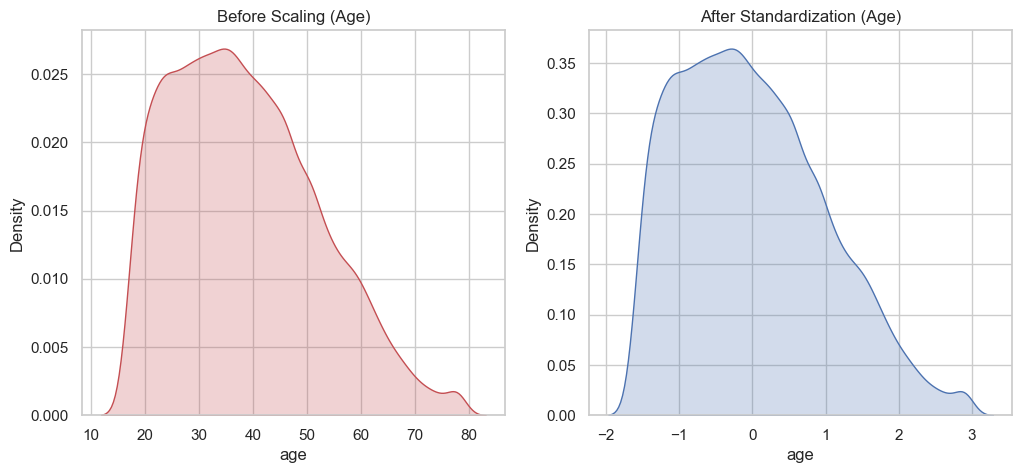

In [90]:
# 3. Visualization: Before vs After
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Before
sns.kdeplot(df['age'], ax=ax1, fill=True, color='r')
ax1.set_title('Before Scaling (Age)')

# After
sns.kdeplot(df_scaled['age'], ax=ax2, fill=True, color='b')
ax2.set_title('After Standardization (Age)')
plt.show()



In [115]:
df["age"].mean()

np.float64(38.585548759873376)

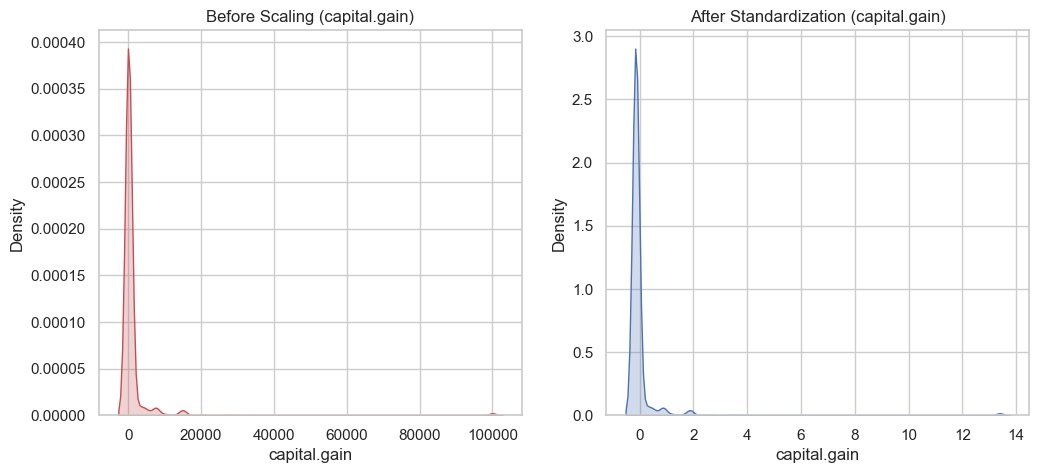

In [119]:
# 3. Visualization: Before vs After (capital gain) this is showing nothing as the column contains 0 value
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Before
sns.kdeplot(df['capital.gain'], ax=ax1, fill=True, color='r')
ax1.set_title('Before Scaling (capital.gain)')

# After
sns.kdeplot(df_scaled['capital.gain'], ax=ax2, fill=True, color='b')
ax2.set_title('After Standardization (capital.gain)')
plt.show()

In [122]:
# so basically there are around 2500  values in capital.gain columns which are filled wiht values
# so there is mean so we can see in the graph the data are concentrated in the 0 value and little bit the data are in side
# after standardization we can the mean is converted to 0 and all the value are converted 
# in the kdeplot there is the  required graph according to the converted values
df['capital.gain'].value_counts()

capital.gain
0        29825
15024      347
7688       284
7298       246
99999      159
         ...  
2538         1
2387         1
1639         1
1455         1
1111         1
Name: count, Length: 119, dtype: int64

In [121]:
df_scaled["capital.gain"].value_counts()

capital.gain
-0.145975     29825
 1.887635       347
 0.894653       284
 0.841864       246
 13.389638      159
              ...  
 0.197562         1
 0.177123         1
 0.075875         1
 0.050970         1
 0.004407         1
Name: count, Length: 119, dtype: int64

## 1️⃣ Nominal Data (Name only)

### What it is:
- Categories with **no natural order or ranking**
- Numbers (if used) are just **labels**, not values
- You **cannot** say one category is greater than another

### Examples:
- Gender: Male, Female  
- Color: Red, Blue, Green  
- Country: India, USA, UK  
- Marital Status: Single, Married  

### Key point:
- **Order does not matter**

### Common encoding:
✔ **One-Hot Encoding**

---

## 2️⃣ Ordinal Data (Ordered categories)

### What it is:
- Categories with a **meaningful order**
- **Unequal or unknown spacing** between levels
- You know the ranking
- You don’t know the exact difference between ranks

### Examples:
- Education level: High School < Bachelor < Master < PhD  
- Satisfaction: Low < Medium < High  
- Movie ratings: Poor < Average < Good < Excellent  

### Key point:
- **Order matters, but differences are not measurable**

### Common encoding:
✔ **Label Encoding** (or custom mapping)

---

## 3️⃣ Discrete Data (Countable numbers)

### What it is:
Numerical values that:
- Are **countable**
- Take **separate, distinct values**
- Are usually **whole numbers**

### Examples:
- Number of children: 0, 1, 2, 3  
- Number of cars owned  
- Number of students in a class  
- Dice outcomes: 1–6  

### Key point:
- **You can count them; no fractions in between**

---

## 4️⃣ Continuous Data (Measurable quantities)

### What it is:
Numerical values that:
- Can take **any value within a range**
- Include **decimals and fractions**

### Examples:
- Height: 170.5 cm  
- Weight: 65.2 kg  
- Temperature: 36.6 °C  
- Salary, Time, Distance  

### Key point:
- **Infinite possible values within a range**

# Encoding Categorical Data

## Encoding Strategies

### 🔢 Label Encoding
- Assigns a **unique integer** to each category  
- Best used for **ordinal data**, where order or rank matters  
  - Examples: `Low < Medium < High`, `Poor < Average < Good`
- Also commonly used for the **target (label) variable**

**Example:**
- Low → 0  
- Medium → 1  
- High → 2  

---

### 🧩 One-Hot Encoding
- Creates **separate binary (0/1) columns** for each category  
- Best used for **nominal data**, where no natural order exists  
  - Examples: `Red`, `Blue`, `Green`
- Prevents models from assuming a false ranking between categories

**Example:**
| Color | Red | Blue | Green |
|------|-----|------|-------|
| Red  | 1   | 0    | 0     |
| Blue | 0   | 1    | 0     |
| Green| 0   | 0    | 1     |

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Label Encoding the Target Variable
le = LabelEncoder()
df['income_encoded'] = le.fit_transform(df['income'])

print("Target Encoding Mapping:")
for i, item in enumerate(le.classes_):
    print(f"{item} --> {i}")

# Drop original income column
df.drop('income', axis=1, inplace=True)

In [ ]:
dff=df_scaled

In [ ]:
# 2. One-Hot Encoding for Nominal Features
# Nominal: Workclass, Marital Status, Occupation, Relationship, Race, Sex
nominal_cols = ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex']

# Using Pandas get_dummies (easiest for EDA phase)
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(f"Shape after One-Hot Encoding: {df_encoded.shape}")

In [ ]:
df

In [ ]:
df['sex'].value_counts()

In [ ]:
df_encoded

In [ ]:
# 3. Label Encoding for Ordinal Features?
if 'education' in df_encoded.columns:
    df_encoded.drop('education', axis=1, inplace=True)

# Update main dataframe
df = df_encoded
display(df.head())

#  Feature Engineering, Selection & Splitting

## Feature Engineering & Selection

### 🔧 Feature Engineering
- **Definition:** Creating new columns or features from existing data to better represent the underlying problem.
- **Purpose:** Helps models capture important patterns and relationships that may not be obvious in the raw data.
- **Example:**  
  ```text
  Net Capital = capital.gain - capital.loss


In [ ]:
df['capital.gain'] = (
    df['capital.gain']
      .replace('?', np.nan)
      .ffill()
)

df['capital.loss'] = (
    df['capital.loss']
      .replace('?', np.nan)
      .ffill()
)

In [ ]:

df['capital.gain']=df['capital.gain'].ffill()
df['capital.loss']=df['capital.loss'].ffill()

In [ ]:
df

In [ ]:
df.info()

In [ ]:
df

In [ ]:
df = = df_encoded

In [ ]:
# 1. Create a new feature: Net Capital
df['net_capital'] = df['capital.gain'] - df['capital.loss']

# 2. Check Correlation
plt.figure(figsize=(20, 15))
# Calculate correlation only on numeric columns
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
# 3. Feature Selection based on Correlation with Target
target_corr = corr_matrix['income_encoded'].sort_values(ascending=False)
print("\nTop 10 features correlated with Income (>50K):")
print(target_corr.head(44))

# Drop columns with extremely low correlation (optional noise reduction)
# keeping features with abs(correlation) > 0.01


relevant_features = target_corr[abs(target_corr) > 0.01].index.tolist()
df_final = df[relevant_features]
print(f"\nReduced feature set from {df.shape[1]} to {df_final.shape[1]}")

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separate Features (X) and Target (y)
X = df_final.drop('income_encoded', axis=1)
y = df_final['income_encoded']

# 2. Split
# stratify=y ensures the proportion of >50k and <=50k is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data Splitting Complete:")
print(f"Training Set: {X_train.shape}")
print(f"Test Set: {X_test.shape}")

# 3. Save processed data (Optional)
X_train.to_csv('X_train_processed.csv', index=False)

In [ ]:
from sklearn.model_selection import train_test_split

X = [[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]]
y = [0, 1, 1, 1, 1,1,1,1,1,0]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train)
print("X_test:", X_test)
print("y_train:", y_train)
print("y_test:", y_test)


In [ ]:
df_final.to_csv('sssgajjg.csv')